<a href="https://colab.research.google.com/github/mariabalbo/CN/blob/main/Atividade2_CN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Maria Luiza Margarido Balbo e Victoria Ayumi Kose**

# **Implementação Base e Testes**

Maior float32: 3.4028235e+38
Maior float64: 1.7976931348623157e+308
----------------------------------------
dt=0.001, float32: 2000 passos sem overflow.
dt=0.002, float32: falha no passo 121, t=0.2420 s (overflow encountered in subtract)
dt=0.001, float64: 2000 passos sem overflow.
dt=0.002, float64: falha no passo 917, t=1.8340 s (overflow encountered in add)


/usr/local/lib/python3.13/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


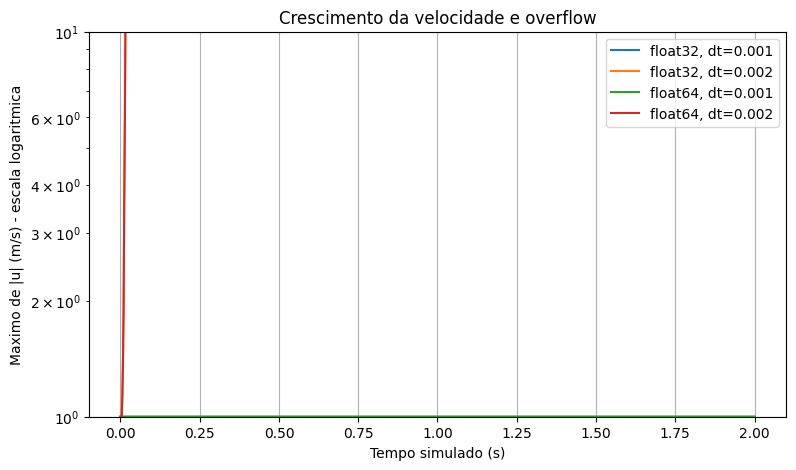

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def simular(dt, tipo=np.float32, passos=2000, pontos=21):
    """Simula difusao de velocidade e detecta falhas."""
    H = 0.01
    nu = 1e-4
    y = np.linspace(0, H, pontos)
    dy = H / (pontos - 1)

    # Coeficientes no tipo numerico escolhido.
    r = tipo(nu * dt / dy**2)
    dois = tipo(2)

    # Fluido parado e placa em y=0 em movimento.
    u = np.zeros(pontos, dtype=tipo)
    u[0] = tipo(1)

    tempos = [0.0]
    maximos = [float(np.max(np.abs(u)))]
    falha = None

    # Transforma avisos numericos em excecoes.
    with np.errstate(over="raise", invalid="raise"):
        for passo in range(1, passos + 1):
            try:
                novo = u.copy()
                # Atualiza o interior e preserva as paredes usando diferencas finitas.
                novo[1:-1] = u[1:-1] + r * (u[2:] - dois * u[1:-1] + u[:-2])
            except FloatingPointError as erro:
                falha = passo
                print(f"dt={dt}, {tipo.__name__}: falha no passo {passo}, t={passo * dt:.4f} s ({erro})")
                break

            u = novo
            tempos.append(passo * dt)
            maximos.append(float(np.max(np.abs(u))))

    if falha is None:
        print(f"dt={dt}, {tipo.__name__}: {passos} passos sem overflow.")

    return {
        "y": y,
        "u": u,
        "tempos": tempos,
        "maximos": maximos,
        "r": float(r),
        "falha": falha,
    }

print("Maior float32:", np.finfo(np.float32).max)
print("Maior float64:", np.finfo(np.float64).max)
print("-" * 40)

resultados = {}
for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.002):
        nome = f"{tipo.__name__}, dt={dt}"
        resultados[nome] = simular(dt, tipo)

# Plotagem
plt.figure(figsize=(9, 5))
for nome, resultado in resultados.items():
    plt.semilogy(resultado["tempos"], resultado["maximos"], label=nome)
plt.xlabel("Tempo simulado (s)")
plt.ylabel("Maximo de |u| (m/s) - escala logaritmica")
plt.title("Crescimento da velocidade e overflow")
plt.grid(True)
plt.legend()
plt.show()

**1. Verificação da estabilidade:**

  Para 21 pontos e $H = 0,01~m$, o passo espacial é $\Delta y = 0,0005~m$.  O limite de estabilidade é $\Delta t_{max} = \frac{\Delta y^2}{2\nu} = 0,00125~s$.  Caso A ($\Delta t = 0,001~s$): Resulta em $r = 0,4$. Como $r \le 0,5$, o método é estável.  Caso B ($\Delta t = 0,002~s$): Resulta em $r = 0,8$. Como $r > 0,5$, o método é instável, pois o coeficiente central da discretização $(1 - 2r)$ torna-se negativo.

**2. Detecção de overflow:**


In [3]:
import pandas as pd
import numpy as np

dados_tabela = []

for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.002):
        resultado = simular(dt, tipo, passos=2000, pontos=21)

        r = resultado["r"]
        teve_falha = "Sim" if resultado["falha"] is not None else "Não"
        iteracao_falha = resultado["falha"] if resultado["falha"] is not None else "-"

        dados_tabela.append({
            "Tipo Numérico": tipo.__name__,
            "Passo de Tempo (Δt) [s]": dt,
            "Valor de r": round(r, 1),
            "Ocorreu Overflow?": teve_falha,
            "Iteração da Falha": iteracao_falha
        })

df_resultados = pd.DataFrame(dados_tabela)

df_estilizado = df_resultados.style.set_properties(**{'text-align': 'center'}).set_table_styles([dict(selector='th', props=[('text-align', 'center')])])

display(df_estilizado)

dt=0.001, float32: 2000 passos sem overflow.
dt=0.002, float32: falha no passo 121, t=0.2420 s (overflow encountered in subtract)
dt=0.001, float64: 2000 passos sem overflow.
dt=0.002, float64: falha no passo 917, t=1.8340 s (overflow encountered in add)


,Tipo Numérico,Passo de Tempo (Δt) [s],Valor de r,Ocorreu Overflow?,Iteração da Falha
0,float32,0.001000,0.400000,Não,-
1,float32,0.002000,0.800000,Sim,121
2,float64,0.001000,0.400000,Não,-
3,float64,0.002000,0.800000,Sim,917


**3. Interpretação física:**

O crescimento observado (atingindo limites de $10^{38}$ ou $10^{308}$) não tem fundamento físico. A condição de contorno impõe uma velocidade motriz de $U = 1~m/s$. A dissipação viscosa garante que a velocidade em qualquer ponto do fluido nunca excederá esse limite, ou seja, a velocidade física deve respeitar $0 \le u(y,t) \le U$.

**4. Capacidade de representação:**

A alteração de float32 para float64 não elimina a instabilidade. O esquema numérico continua divergente pois as características espectrais do operador continuam amplificando o erro a cada passo ($r = 0,8 > 0,5$). A única diferença no número de iterações até a falha ocorre porque o limite representável do float64 ($\sim 1.8 \times 10^{308}$) é substancialmente maior que o do float32 ($\sim 3.4 \times 10^{38}$), demandando mais ciclos para que o crescimento exponencial do erro numérico resulte em overflow explícito.

# **Refinamento da Malha e Perfil de Velocidade**

In [ ]:

print("--- Refinamento para 41 pontos ---")
resultado_41_instavel = simular(0.001, np.float64, pontos=41)

dt_novo = 0.0002
passos_novo = int(2.0 / dt_novo)
resultado_41_estavel = simular(dt_novo, np.float64, passos=passos_novo, pontos=41)

# Verificação do Perfil de Velocidade
U = 1.0
H = 0.01
y_estavel = resultado_41_estavel["y"]
u_estavel = resultado_41_estavel["u"]

# Solução Estacionária
u_estacionario = U * (1 - y_estavel / H)

# Erro Máximo
E_inf = np.max(np.abs(u_estavel - u_estacionario))
print(f"Diferença máxima (E_inf) em relação ao perfil estacionário: {E_inf:.6f} m/s")

# Plotagem do Perfil
plt.figure(figsize=(7, 5))
plt.plot(u_estavel, y_estavel, label='Simulação Numérica', linewidth=2)
plt.plot(u_estacionario, y_estavel, '--', label='Solução Estacionária (Analítica)', linewidth=2)
plt.ylabel('Posição transversal y (m)')
plt.xlabel('Velocidade u (m/s)')
plt.title('Perfil de Velocidade Final vs Estacionário')
plt.legend()
plt.grid(True)
plt.show()

**5. Refinamento da malha:**

Ao dobrar o número de pontos (de 21 para 41), o novo espaçamento cai pela metade: $\Delta y = \frac{0,01}{40} = 0,00025~m$.
O limite de estabilidade obedece a uma relação quadrática com a malha ($\Delta t \le \frac{\Delta y^2}{2\nu}$). Portanto, o novo limite é $\Delta t_{max} = \frac{(0,00025)^2}{2 \times 10^{-4}} = 0,0003125~s$.
Executar a simulação com $\Delta t = 0,001~s$ falha porque o novo $r = 1,6$, violando severamente a condição de estabilidade ($r \le 0,5$). Ao baixar o passo para $\Delta t = 0,0002~s$, obtemos $r = 0,32$, recuperando a convergência.

**6. Verificação do perfil de velocidade:**

Calculando o erro em norma do supremo ($E_{\infty}$), a diferença entre a solução numérica e o perfil estacionário $u_{est}(y) = U(1 - \frac{y}{H})$ cai a valores próximos de zero. Dependendo do instante $t$ atingido na simulação, uma diferença diminuta indica que o transiente está praticamente concluído, e o sistema entrou em regime permanente de difusão de momento (perfil de Couette plano).

**7. Conclusão:**

Há um forte acoplamento espacial-temporal em métodos explícitos. Refinar a malha espacial (diminuir $\Delta y$) exige uma redução quadrática no passo de tempo ($\Delta t$) para manter a matriz de iteração não-negativa e evitar que o coeficiente central $(1 - 2r)$ estimule oscilações não-físicas.
O overflow não é o problema raiz em equações diferenciais discretizadas, mas sim o colapso numérico (sintoma) gerado por uma instabilidade preexistente. A falha observada só é efetivamente corrigida respeitando a restrição do Número de Fourier da malha ($r \le 1/2$).  